| Thuật ngữ | Giải thích |
|---|---|
| **Symbol/Ticker** | Mã viết tắt dùng để nhận diện cổ phiếu, ví dụ `AAPL` là Apple và `JPM` là JPMorgan Chase. |
| **Trading session** | Một phiên giao dịch trên thị trường chứng khoán. Dữ liệu sử dụng một observation cho mỗi cổ phiếu trong mỗi phiên. |
| **OHLCV** | Năm thông tin cơ bản của một phiên giao dịch: Open, High, Low, Close và Volume. |
| **Open** | Giá của cổ phiếu tại thời điểm mở cửa phiên giao dịch. |
| **High** | Giá cao nhất được ghi nhận trong phiên. |
| **Low** | Giá thấp nhất được ghi nhận trong phiên. |
| **Close** | Giá của cổ phiếu tại thời điểm đóng cửa phiên giao dịch. |
| **Volume** | Tổng số cổ phiếu được giao dịch trong phiên. Volume cao thường thể hiện mức độ tham gia lớn của nhà đầu tư. |
| **Split-adjusted price** | Giá đã được điều chỉnh để hạn chế sự thay đổi giả tạo do chia tách cổ phiếu. Nhờ đó, return tính qua các thời điểm chia tách phản ánh biến động thị trường hợp lý hơn. |
| **Return** | Tỷ suất thay đổi của giá đóng cửa so với phiên trước. Return dương thể hiện giá tăng, còn return âm thể hiện giá giảm. |
| **Intraday range** | Biên độ dao động giá trong một phiên, được đo từ giá thấp nhất đến giá cao nhất và chuẩn hóa theo giá mở cửa. |
| **Volatility** | Mức độ biến động của return. Volatility cao nghĩa là return thay đổi mạnh và khó ổn định hơn, nhưng không cho biết giá đang tăng hay giảm. |
| **Fundamentals** | Các thông tin phản ánh tình hình tài chính của doanh nghiệp như doanh thu, lợi nhuận, tài sản, nợ và vốn chủ sở hữu. |
| **EPS** | Earnings Per Share, tức lợi nhuận dành cho mỗi cổ phiếu phổ thông. EPS thường được tính bằng lợi nhuận dành cho cổ đông phổ thông chia cho số cổ phiếu lưu hành. |
| **GICS Sector** | Nhóm ngành kinh tế của doanh nghiệp theo hệ thống Global Industry Classification Standard. |
| **GICS Sub Industry** | Phân ngành chi tiết hơn bên trong một GICS Sector. |

## 1. Mục tiêu

Notebook thực hiện khám phá, kiểm tra chất lượng và chuẩn bị dữ liệu trước khi xây dựng mô hình Machine Learning.

Phân tích tập trung vào 8 cổ phiếu thuộc các nhóm ngành khác nhau:

**AAPL, AMZN, JPM, MRK, XOM, KO, BA và NEE.**

Các mục tiêu chính gồm:

- Khám phá đặc điểm phân phối của giá, lợi suất và khối lượng giao dịch.
- Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và các giá trị OHLCV không hợp lệ.
- Phát hiện các biến động bất thường bằng IQR và Z-score.
- Phân tích outlier trong bối cảnh khối lượng giao dịch và biến động thị trường.
- Xử lý missing values dựa trên nguyên nhân và ý nghĩa của từng biến.
- Tích hợp thông tin ngành và tạo thêm các đặc trưng phục vụ phân tích.
- Chuẩn bị dữ liệu cho các bài toán dự báo hoặc phân loại ở các bước tiếp theo.

## 2. Dữ liệu đầu vào

Notebook sử dụng ba nguồn dữ liệu:

1. **prices-split-adjusted.csv**  
   Dữ liệu giá cổ phiếu đã điều chỉnh theo từng phiên, gồm ngày giao dịch, mã cổ phiếu, giá mở cửa, đóng cửa, cao nhất, thấp nhất và khối lượng giao dịch.

2. **securities.csv**  
   Thông tin mô tả doanh nghiệp (tên công ty, ngành và phân ngành GICS)

3. **fundamentals.csv**  
   Dữ liệu tài chính hằng năm như doanh thu, lợi nhuận, tài sản, nợ, vốn chủ sở hữu, các tỷ số tài chính và EPS.

Mỗi record trong dữ liệu giá đại diện cho một cổ phiếu tại một phiên giao dịch.

## 3. Kết quả đầu ra

các tập dữ liệu đã được làm sạch, tích hợp và bổ sung đặc trưng, sẵn sàng cho những bước phân tích hoặc xây dựng mô hình sau này.

### 3.1. Dữ liệu giá cổ phiếu sau xử lý

Tập dữ liệu chính là `COMP_2016`, chứa dữ liệu giao dịch năm 2016 của 8 cổ phiếu đã chọn. Mỗi dòng đại diện cho một cổ phiếu tại một phiên giao dịch.

Ngoài các biến OHLCV ban đầu, tập dữ liệu được bổ sung các đặc trưng sau:

| Đặc trưng | Ý nghĩa |
|---|---|
| `return` | Tỷ suất sinh lời của cổ phiếu so với phiên giao dịch trước. |
| `intraday_range` | Biên độ dao động giá trong cùng một phiên so với giá mở cửa. |
| `log_volume` | Logarithm của khối lượng giao dịch, giúp giảm ảnh hưởng của các giá trị volume quá lớn. |
| `volume_ma_20` | Khối lượng giao dịch trung bình của 20 phiên trước đó. |
| `relative_volume` | Tỷ lệ giữa volume hiện tại và volume trung bình của 20 phiên trước. |
| `volatility_20` | Độ lệch chuẩn của return trong 20 phiên trước, đại diện cho mức biến động gần đây. |
| `iqr_outlier` | Cho biết return có bị xem là outlier theo phương pháp IQR hay không. |
| `z_score` | Cho biết return hiện tại cách giá trị trung bình bao nhiêu độ lệch chuẩn. |
| `is_outlier` | Bằng `True` nếu observation được phát hiện là outlier bởi IQR hoặc Z-score. |
| `abs_return` | Độ lớn tuyệt đối của return, không phân biệt giá tăng hay giảm. |
| `volume_spike` | Cho biết volume hiện tại có lớn ít nhất gấp 2 lần mức trung bình 20 phiên trước hay không. |
| `high_prior_volatility` | Cho biết observation xuất hiện sau một giai đoạn có volatility tương đối cao hay không. |
| `GICS Sector` | Ngành kinh tế của doanh nghiệp. |
| `GICS Sub Industry` | Phân ngành chi tiết của doanh nghiệp. |

Một số đặc trưng được tính như sau:

\[
Return_t = \frac{Close_t}{Close_{t-1}} - 1
\]

Trong đó `return = 0.03` có nghĩa là giá đóng cửa tăng 3% so với phiên trước, còn `return = -0.03` nghĩa là giá giảm 3%.

\[
IntradayRange_t =
\frac{High_t-Low_t}{Open_t}
\]

Chỉ số này mô tả mức dao động của giá trong một phiên. Giá trị càng lớn thì biên độ biến động trong ngày càng cao.

\[
RelativeVolume_t =
\frac{Volume_t}
{\text{Mean}(Volume_{t-20},...,Volume_{t-1})}
\]

Ví dụ, `relative_volume = 2` nghĩa là volume hiện tại bằng hai lần volume trung bình của 20 phiên trước.

`volatility_20` được tính bằng độ lệch chuẩn của return trong 20 phiên trước. Giá trị này càng cao thì cổ phiếu vừa trải qua một giai đoạn biến động càng mạnh.

### 3.2. Kết quả phát hiện outlier

Notebook tạo các biến đánh dấu những phiên có return bất thường:

- `iqr_outlier`: outlier được phát hiện bằng khoảng tứ phân vị IQR.
- `z_score`: mức độ khác biệt của return so với trung bình.
- `is_outlier`: kết hợp kết quả của hai phương pháp trên.

Outlier trong dữ liệu chứng khoán không nhất thiết là lỗi dữ liệu. Một phiên tăng hoặc giảm mạnh có thể phản ánh:

- Tin tức liên quan đến doanh nghiệp.
- Biến động chung của thị trường hoặc ngành.
- Thay đổi mạnh về khối lượng giao dịch.
- Một giai đoạn thị trường có volatility hay có biến động cao.
- Sự kiện đặc biệt hoặc lỗi trong quá trình thu thập dữ liệu.

Nên có giữ lại outlier để phục vụ ptich

Bảng `outlier_context` tổng hợp kết quả theo từng cổ phiếu:

| Chỉ số | Giải thích |
|---|---|
| `outlier_count` | Tổng số phiên giao dịch của từng cổ phiếu được xác định là có return bất thường bởi phương pháp IQR hoặc Z-score. |
| `avg_abs_return` | Độ lớn return trung bình trong các phiên outlier, không phân biệt tăng hay giảm. Ví dụ, giá trị `0.04` nghĩa là trong các phiên outlier, giá cổ phiếu biến động trung bình khoảng 4%. |
| `avg_relative_volume` | Khối lượng giao dịch trung bình trong các phiên outlier so với mức trung bình của 20 phiên giao dịch trước. Ví dụ, giá trị `1.5` nghĩa là volume trong các phiên outlier trung bình bằng 1.5 lần mức thông thường. |
| `volume_spike_count` | Số phiên vừa được xác định là outlier về return, vừa có khối lượng giao dịch ít nhất gấp 2 lần khối lượng trung bình của 20 phiên giao dịch trước đó. |
| `high_volatility_count` | Số phiên outlier xuất hiện sau khi cổ phiếu vừa trải qua một giai đoạn biến động cao. Trong notebook, biến động cao nghĩa là `volatility_20` lớn hơn tứ phân vị thứ ba (Q3) của chính cổ phiếu đó trong năm 2016. |
| `volume_spike_rate` | Tỷ lệ các phiên outlier có volume tăng đột biến, được tính bằng `volume_spike_count / outlier_count`. Ví dụ, giá trị `0.30` nghĩa là 30% số phiên outlier có volume ít nhất gấp đôi mức trung bình 20 phiên trước. |
| `high_volatility_rate` | Tỷ lệ các phiên outlier xuất hiện sau một giai đoạn có volatility cao, được tính bằng `high_volatility_count / outlier_count`. Ví dụ, giá trị `0.40` nghĩa là 40% số phiên outlier xảy ra khi volatility của 20 phiên trước đang ở mức cao. |

Các chỉ số này giúp đánh giá liệu một biến động giá bất thường có đi kèm khối lượng giao dịch lớn hoặc xuất hiện trong một giai đoạn thị trường vốn đã biến động mạnh hay không.

### 3.3. Dữ liệu tài chính sau xử lý

Tập dữ liệu `fund_clean` là dữ liệu fundamentals của 8 doanh nghiệp sau khi xử lý missing values.

Các kết quả xử lý bao gồm:

- Bổ sung `For Year` từ năm của `Period Ending` nếu năm tài chính bị thiếu.
- Tạo `for_year_was_missing` để ghi nhận giá trị nào từng bị thiếu.
- Tạo `shares_was_missing` để đánh dấu số lượng cổ phiếu lưu hành bị thiếu.
- Tạo `eps_was_missing` để đánh dấu EPS bị thiếu.
- Điền số lượng cổ phiếu lưu hành từ kỳ gần nhất trước đó của cùng doanh nghiệp.
- Tính lại EPS từ lợi nhuận dành cho cổ đông phổ thông và số lượng cổ phiếu khi đủ dữ liệu.

Một số tỷ số thanh khoản bị thiếu của JPM được giữ nguyên vì đây là missing value có tính cấu trúc. Các tỷ số này không thể tính theo công thức thông thường khi dữ liệu current assets và current liabilities không phù hợp với cách trình bày báo cáo tài chính của ngân hàng.

### 3.4. Kết quả kiểm tra chất lượng dữ liệu

Notebook kiểm tra:

- Các dòng bị trùng theo cặp khóa `symbol` và `date`.
- Khối lượng giao dịch âm.
- Giá thấp nhất lớn hơn giá mở cửa hoặc giá đóng cửa.
- Giá cao nhất nhỏ hơn giá mở cửa hoặc giá đóng cửa.

Những kiểm tra này giúp đảm bảo dữ liệu tuân theo các quan hệ OHLCV cơ bản trước khi được sử dụng cho phân tích hoặc huấn luyện mô hình.

---

## 4. Các kỹ thuật được sử dụng

Notebook chọn 8 cổ phiếu thuộc các ngành khác nhau và sắp xếp dữ liệu theo mã cổ phiếu, ngày giao dịch. Việc này bảo đảm return và các đặc trưng theo thời gian được tính đúng thứ tự.

### 4.1. Tạo và biến đổi đặc trưng

Các đặc trưng mới được tạo từ dữ liệu OHLCV:

- `return`: mức thay đổi giá so với phiên trước.
- `intraday_range`: biên độ dao động giá trong phiên.
- `log_volume`: nén các giá trị volume quá lớn.
- `relative_volume`: so sánh volume hiện tại với trung bình 20 phiên trước.
- `volatility_20`: đo mức biến động của return trong 20 phiên trước.

Các đặc trưng này có ý nghĩa phân tích tốt hơn so với chỉ sử dụng giá và volume ban đầu.

### 4.2. Phát hiện và phân tích outlier

Notebook sử dụng hai phương pháp:

- **IQR:** phát hiện giá trị nằm ngoài khoảng phân bố thông thường.
- **Z-score:** phát hiện giá trị cách xa trung bình trên 3 độ lệch chuẩn.

Kết quả của hai phương pháp được kết hợp trong biến `is_outlier`. Sau đó, notebook dùng relative volume và volatility để xem outlier có đi kèm volume lớn hoặc xuất hiện sau giai đoạn biến động cao hay không.

Outlier được giữ lại để phân tích vì biến động mạnh trong chứng khoán không nhất thiết là lỗi dữ liệu.

### 4.3. Tích hợp và xử lý dữ liệu thiếu

Dữ liệu giá được kết hợp với thông tin ngành thông qua mã cổ phiếu.

Missing values được xử lý tùy theo ý nghĩa của từng cột:

- Suy ra `For Year` từ `Period Ending`.
- Forward fill (điền theo ngày gần nhất) số cổ phiếu lưu hành trong cùng doanh nghiệp.
- Tính lại EPS khi có đủ dữ liệu.
- Tạo các cột đánh dấu giá trị từng bị thiếu.
- Giữ nguyên missing values có tính cấu trúc thay vì điền tùy ý.

### 4.4. Kiểm tra chất lượng dữ liệu

kiểm tra:

- Dòng dữ liệu bị trùng theo `symbol` và `date`.
- Volume âm.
- Các giá trị open, high, low và close vi phạm quan hệ OHLCV.

Bước này giúp phát hiện lỗi dữ liệu trước khi dữ liệu được sử dụng cho phân tích hoặc Machine Learning.

## 5. Phạm vi và lưu ý

Notebook hiện tập trung vào giai đoạn **khám phá và chuẩn bị dữ liệu**, chưa thực hiện huấn luyện mô hình dự đoán.

Các outlier được phát hiện là bất thường về mặt thống kê nhưng không nhất thiết là lỗi dữ liệu. Trong thị trường tài chính, chúng có thể phản ánh tin tức, cú sốc thị trường hoặc những giai đoạn biến động mạnh. Vì vậy, các giá trị này được giữ lại và bổ sung cờ nhận diện thay vì tự động loại bỏ.

Kết quả của notebook có thể được sử dụng làm dữ liệu đầu vào cho các bài toán tiếp theo như dự báo lợi suất, dự báo biến động hoặc phân loại phiên giảm giá mạnh.

In [109]:
import pandas as pd
import numpy as np

fund = pd.read_csv('../../dataset/fundamentals.csv', index_col=0)
prices = pd.read_csv('../../dataset/prices-split-adjusted.csv')
securities = pd.read_csv('../../dataset/securities.csv', index_col=0)

In [110]:
fund_cols = [
    'Total Revenue',
    'Gross Profit',
    'Operating Income',
    'Net Income',
    'Total Assets',
    'Total Liabilities',
    'Total Equity',
    'Net Cash Flow-Operating',
    'Profit Margin',
    'Current Ratio',
    'After Tax ROE',
    'Earnings Per Share'
]

fund[fund_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Total Revenue,1781.0,2.029154e+10,4.095355e+10,1.514000e+06,3.714000e+09,8.023200e+09,1.748600e+10,4.856510e+11
Gross Profit,1781.0,7.189010e+09,1.360778e+10,-1.264700e+10,1.581900e+09,2.991000e+09,6.944000e+09,1.494530e+11
Operating Income,1781.0,2.268980e+09,5.061444e+09,-2.791000e+10,5.258610e+08,1.021015e+09,2.260000e+09,7.123000e+10
Net Income,1781.0,1.705517e+09,3.993401e+09,-2.352800e+10,3.528200e+08,6.860880e+08,1.697000e+09,5.339400e+10
Total Assets,1781.0,5.570921e+10,2.033590e+11,2.705000e+06,6.552689e+09,1.517000e+10,3.599710e+10,2.572274e+12
Total Liabilities,1781.0,4.380420e+10,1.817039e+11,2.577000e+06,3.843300e+09,9.141000e+09,2.389700e+10,2.340547e+12
Total Equity,1781.0,1.188846e+10,2.584429e+10,-1.324400e+10,2.201492e+09,4.983000e+09,1.080900e+10,2.562050e+11
Net Cash Flow-Operating,1781.0,3.257626e+09,7.397563e+09,-1.605600e+10,6.641750e+08,1.237000e+09,3.048639e+09,1.079530e+11
Profit Margin,1781.0,1.395789e+01,1.755966e+01,0.000000e+00,6.000000e+00,1.000000e+01,1.700000e+01,3.690000e+02
Current Ratio,1482.0,1.867713e+02,1.280668e+02,1.700000e+01,1.090000e+02,1.520000e+02,2.260000e+02,1.197000e+03


In [111]:
fund.head()

,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,1.330000e+09,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,2.175000e+09,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,1.768000e+09,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,1.085000e+09,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,5.981110e+08,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


In [112]:
prices.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [113]:
prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [114]:
print('Number of symbols:', prices['symbol'].nunique())
prices['symbol'].value_counts().describe()

Number of symbols: 501


count     501.000000
mean     1699.129741
std       253.731238
min       126.000000
25%      1762.000000
50%      1762.000000
75%      1762.000000
max      1762.000000
Name: count, dtype: float64

In [115]:
securities.head()

,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
Ticker symbol,,,,,,,
MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877


In [116]:
COMP_SYMBOL = ['AAPL', 'AMZN','JPM', 'MRK', 'XOM', 'KO', 'BA', 'NEE']

prices['date'] = pd.to_datetime(prices['date'])

prices = prices.sort_values(
    ['symbol', 'date']
).reset_index(drop=True)

COMP = prices[
    prices['symbol'].isin(COMP_SYMBOL)
].copy()

COMP['return'] = COMP.groupby('symbol')['close'].pct_change()


# Biên độ biến động bên trong phiên
COMP['intraday_range'] = (
    (COMP['high'] - COMP['low'])
    / COMP['open']
)

# Giảm độ lệch phải của volume Một vài ngày có volume hàng trăm triệu sẽ làm histogram khó quan sát -> nén gtri lớn, phục vụ visualize và scale
COMP['log_volume'] = np.log1p(COMP['volume'])

# Volume trung bình của 20 phiên TRƯỚC
COMP['volume_ma_20'] = (
    COMP.groupby('symbol')['volume']
    .transform(
        lambda x: x.shift(1)
                   .rolling(20, min_periods=20)
                   .mean()
    )
)

# Volume hiện tại lớn gấp bao nhiêu lần bình thường
COMP['relative_volume'] = (
    COMP['volume']
    / COMP['volume_ma_20']
)



# Volatility của 20 phiên TRƯỚC
COMP['volatility_20'] = (
    COMP.groupby('symbol')['return']
    .transform(
        lambda x: x.shift(1)
                   .rolling(20, min_periods=20)
                   .std()
    )
)

COMP_2016 = COMP[
    COMP['date'].between('2016-01-01', '2016-12-31')
].copy()

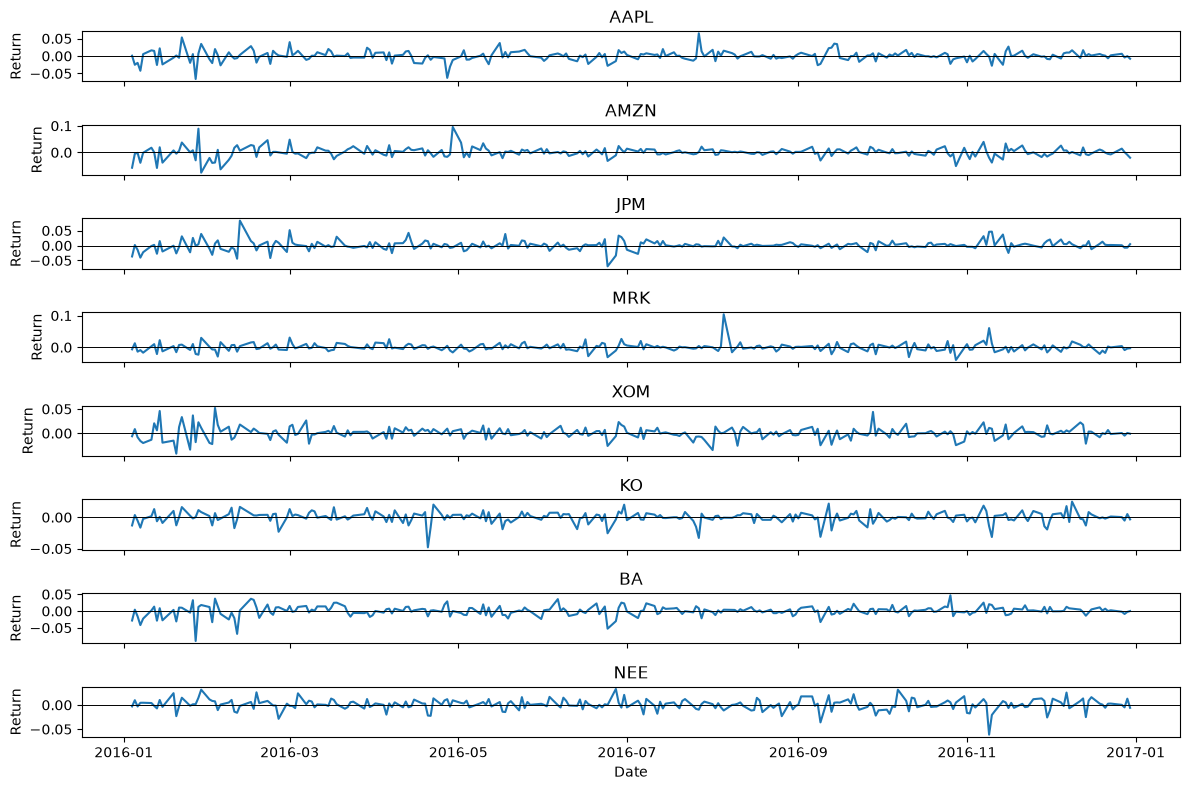

In [117]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(
    len(COMP_SYMBOL), 1,
    figsize=(12, 8),
    sharex=True
)

for ax, symbol in zip(axes, COMP_SYMBOL):
    stock = (
        COMP_2016[COMP_2016['symbol'] == symbol]
        .sort_values('date')
    )

    ax.plot(stock['date'], stock['return'])
    ax.set_title(symbol)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_ylabel('Return')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

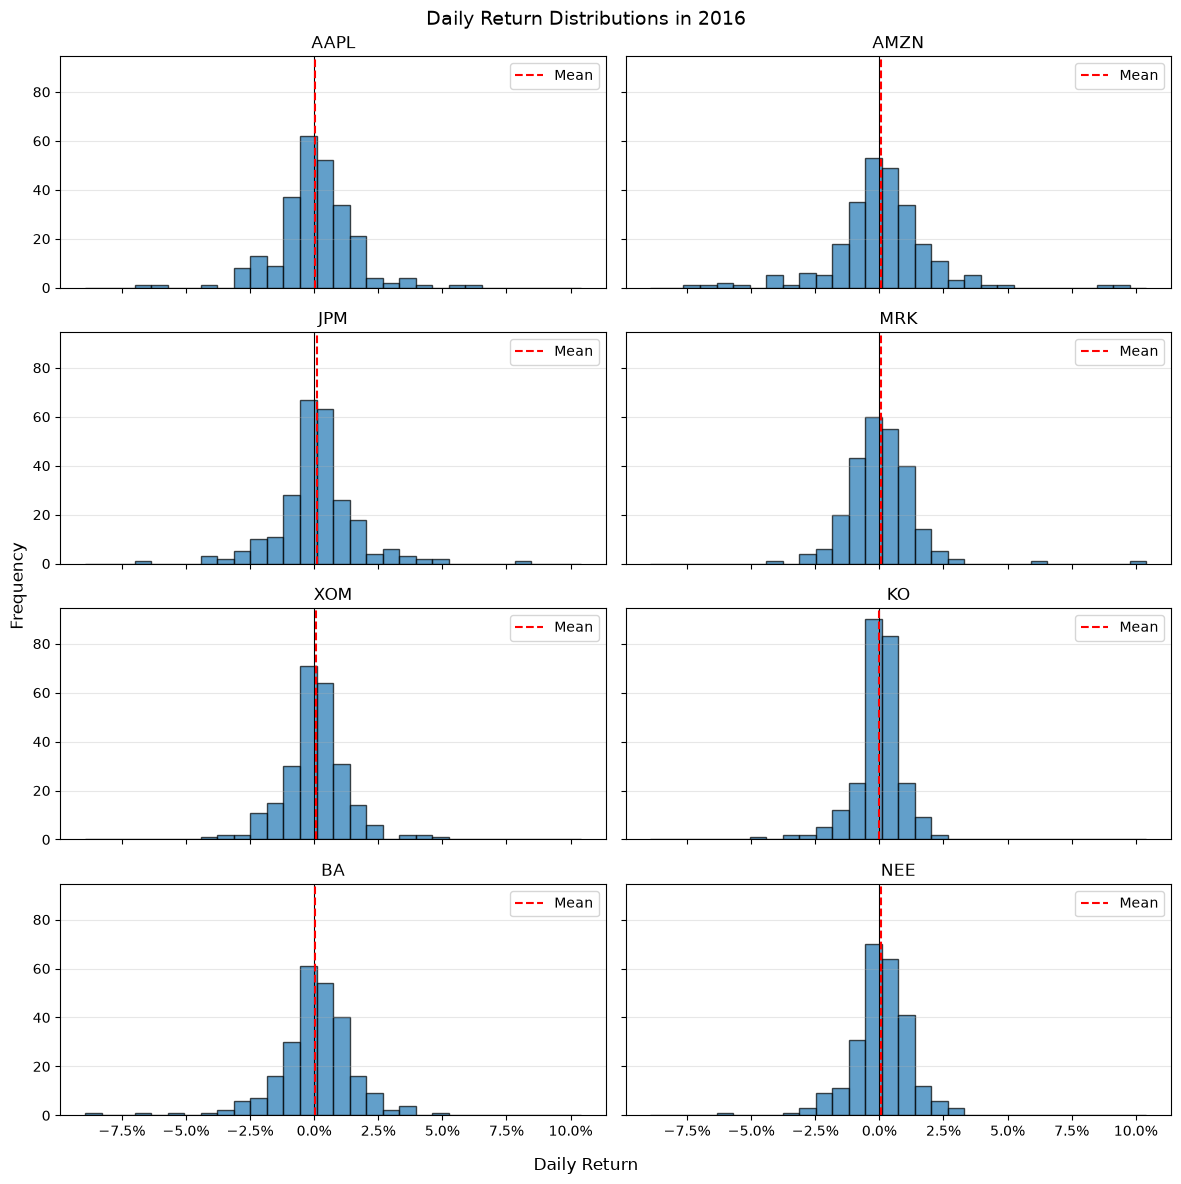

In [118]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Dùng chung khoảng chia để dễ so sánh giữa các mã
all_returns = COMP_2016['return'].dropna()
bins = np.histogram_bin_edges(all_returns, bins=30)

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 12),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, symbol in zip(axes, COMP_SYMBOL):
    stock_return = COMP_2016.loc[
        COMP_2016['symbol'] == symbol,
        'return'
    ].dropna()

    ax.hist(
        stock_return,
        bins=bins,
        edgecolor='black',
        alpha=0.7
    )

    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(
        stock_return.mean(),
        color='red',
        linestyle='--',
        label='Mean'
    )

    ax.set_title(symbol)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

fig.supxlabel('Daily Return')
fig.supylabel('Frequency')
fig.suptitle('Daily Return Distributions in 2016', fontsize=14)

plt.tight_layout()
plt.show()

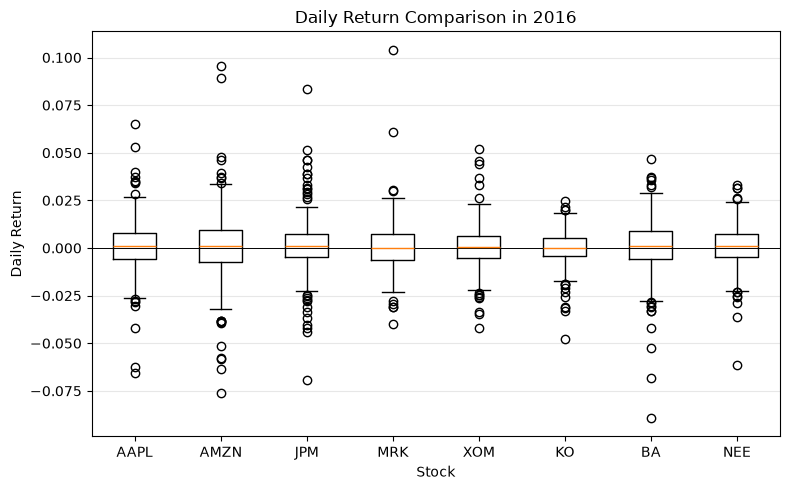

In [119]:
plt.figure(figsize=(8, 5))

return_data = [
    COMP_2016.loc[
        COMP_2016['symbol'] == symbol,
        'return'
    ].dropna()
    for symbol in COMP_SYMBOL
]

plt.boxplot(return_data, tick_labels=COMP_SYMBOL)

plt.xlabel('Stock')
plt.ylabel('Daily Return')
plt.title('Daily Return Comparison in 2016')
plt.axhline(0, color='black', linewidth=0.7)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [120]:
# IQR - show outliers
grouped = COMP_2016.groupby('symbol')['return']

q1 = grouped.transform(lambda x: x.quantile(0.25))
q3 = grouped.transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

COMP_2016['iqr_outlier'] = (
    (COMP_2016['return'] < q1 - 1.5 * iqr) |
    (COMP_2016['return'] > q3 + 1.5 * iqr)
)
COMP_2016.groupby('symbol')['iqr_outlier'].sum()

symbol
AAPL    15
AMZN    18
BA      16
JPM     27
KO      14
MRK      9
NEE     12
XOM     14
Name: iqr_outlier, dtype: int64

In [121]:
#  Z score

COMP_2016 = COMP_2016.copy()

COMP_2016['z_score'] = (
    COMP_2016.groupby('symbol')['return']
    .transform(lambda x: (x - x.mean()) / x.std())
)

outliers = COMP_2016[COMP_2016['z_score'].abs() > 3]
outliers.groupby('symbol')['z_score'].count()


# IQR vốn nhạy hơn z score vì IQR bắt outlier ở khoảng +-2,7 trong khi z score +-3 
# và zscore nhạy hơn với gtri cực đoan - gtri mà trong stock price có rất nhiều
# Những observation được phát hiện bởi IQR hoặc Z-score là outlier về mặt thống kê, nhưng không nhất thiết là lỗi dữ liệu.
#  riêng trong finance thì những outlier này có thể là những biến động bất thường của thị trường, hoặc các sự kiện đặc biệt ảnh hưởng đến giá cổ phiếu.
#  cần giữ lại những outlier này de ptich, vì mang thông tin quan trọng về rủi ro và biến động của cổ phiếu hỗ trợ việc huấn luyện ra mô hình ôn định hơn.

symbol
AAPL    4
AMZN    6
BA      4
JPM     3
KO      4
MRK     3
NEE     2
XOM     4
Name: z_score, dtype: int64

In [122]:
# tổng hợp outlier

COMP_2016['is_outlier'] = (
    COMP_2016['iqr_outlier'] |
    (COMP_2016['z_score'].abs() > 3)
)
COMP_2016.groupby('symbol')['is_outlier'].agg(
    ['sum', 'mean']
)


,sum,mean
symbol,,
AAPL,15,0.059524
AMZN,18,0.071429
BA,16,0.063492
JPM,27,0.107143
KO,14,0.055556
MRK,9,0.035714
NEE,12,0.047619
XOM,14,0.055556


In [123]:
COMP_2016['volume_spike'] = (
    COMP_2016['relative_volume'] >= 2
)

COMP_2016['abs_return'] = (
    COMP_2016['return'].abs()
)

volatility_q3 = (
    COMP_2016
    .groupby('symbol')['volatility_20']
    .transform(lambda x: x.quantile(0.75))
)

COMP_2016['high_prior_volatility'] = (
    COMP_2016['volatility_20'] > volatility_q3
)

outlier_rows = COMP_2016[
    COMP_2016['is_outlier']
].copy()

outlier_context = (
    outlier_rows
    .groupby('symbol')
    .agg(
        outlier_count=('is_outlier', 'size'),
        avg_abs_return=('abs_return', 'mean'),
        avg_relative_volume=('relative_volume', 'mean'),
        volume_spike_count=('volume_spike', 'sum'),
        high_volatility_count=(
            'high_prior_volatility',
            'sum'
        )
    )
)

outlier_context['volume_spike_rate'] = (
    outlier_context['volume_spike_count']
    / outlier_context['outlier_count']
)

outlier_context['high_volatility_rate'] = (
    outlier_context['high_volatility_count']
    / outlier_context['outlier_count']
)

outlier_context

# outlier_count	Tổng số ngày có is_outlier = True.
# avg_abs_return	Trung bình độ lớn tuyệt đối của return trong các ngày outlier. Không phân biệt tăng hay giảm. Ví dụ 0.0407 nghĩa là biến động trung bình 4.07%.
# avg_relative_volume	Khối lượng giao dịch trung bình của ngày outlier so với trung bình 20 phiên trước. Ví dụ 1.92 nghĩa là volume bằng khoảng 1.92 lần bình thường.
# volume_spike_count	Số ngày outlier đồng thời có relative_volume >= 2, tức volume ít nhất gấp đôi trung bình 20 phiên trước.
# high_volatility_count	Số ngày outlier xuất hiện khi volatility của 20 phiên trước đang ở mức cao. Trong code của bạn, “cao” nghĩa là vượt Q3 của từng cổ phiếu.
# volume_spike_rate	Tỷ lệ ngày outlier có volume spike: volume_spike_count / outlier_count.
# high_volatility_rate	Tỷ lệ ngày outlier xuất hiện sau giai đoạn volatility cao: high_volatility_count / outlier_count.

,outlier_count,avg_abs_return,avg_relative_volume,volume_spike_count,high_volatility_count,volume_spike_rate,high_volatility_rate
symbol,,,,,,,
AAPL,15,0.040721,1.924565,7,6,0.466667,0.400000
AMZN,18,0.051501,1.780366,6,11,0.333333,0.611111
BA,16,0.041114,2.073109,4,9,0.250000,0.562500
JPM,27,0.037689,1.756657,6,9,0.222222,0.333333
KO,14,0.025529,1.878868,5,4,0.357143,0.285714
MRK,9,0.042718,2.570819,3,0,0.333333,0.000000
NEE,12,0.030912,1.512502,3,3,0.250000,0.250000
XOM,14,0.033893,1.591520,4,6,0.285714,0.428571


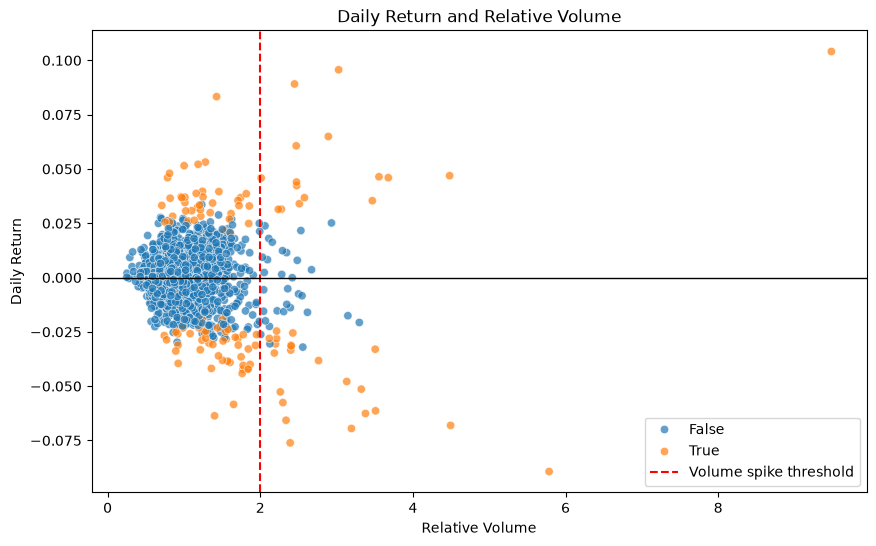

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=COMP_2016,
    x='relative_volume',
    y='return',
    hue='is_outlier',
    alpha=0.7
)

plt.axvline(
    2,
    color='red',
    linestyle='--',
    label='Volume spike threshold'
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.xlabel('Relative Volume')
plt.ylabel('Daily Return')
plt.title('Daily Return and Relative Volume')
plt.legend()
plt.show()

# Thấp, bên trái	Biến động giá nhỏ, volume bình thường
# Thấp, bên phải	Volume tăng mạnh nhưng giá chưa biến động nhiều
# Cao, bên trái	Giá biến động bất thường nhưng volume không tăng mạnh
# Cao, bên phải	Giá biến động bất thường và volume cũng tăng mạnh

In [125]:
metadata = (
    securities[
        ['Security', 'GICS Sector', 'GICS Sub Industry'] #k cần lấy CIK, DATE FIRST ADD, ....
    ]
    .reset_index()
)

COMP_2016 = COMP_2016.merge(
    metadata,
    left_on='symbol',
    right_on='Ticker symbol',
    how='left',
    validate='many_to_one'
)

In [126]:
COMP_2016.groupby('GICS Sector')['return'].agg(
    ['mean', 'std', 'min', 'max']
)

,mean,std,min,max
GICS Sector,,,,
Consumer Discretionary,0.000586,0.018711,-0.076100,0.095664
Consumer Staples,-0.000100,0.009078,-0.047854,0.024890
Energy,0.000655,0.012157,-0.042147,0.052152
Financials,0.001184,0.015624,-0.069477,0.083286
Health Care,0.000516,0.013252,-0.039974,0.104080
Industrials,0.000410,0.015212,-0.089290,0.046900
Information Technology,0.000488,0.014722,-0.065707,0.064963
Utilities,0.000618,0.011304,-0.061357,0.032956


In [127]:
fund_comp = fund[
    fund['Ticker Symbol'].isin(COMP_SYMBOL)
].copy()

fund_comp['Period Ending'] = pd.to_datetime(
    fund_comp['Period Ending']
)

fund_comp = fund_comp.sort_values(
    ['Ticker Symbol', 'Period Ending']
)

missing_before = pd.DataFrame({
    'missing_count': fund_comp.isna().sum(),
    'missing_percent': fund_comp.isna().mean() * 100
})

missing_before = missing_before[
    missing_before['missing_count'] > 0
]

missing_before

,missing_count,missing_percent
Cash Ratio,4,12.50
Current Ratio,4,12.50
Quick Ratio,4,12.50
For Year,2,6.25
Earnings Per Share,2,6.25
Estimated Shares Outstanding,2,6.25


In [128]:
# xly missing cho for year ( lấy luôn năm từ period ending nếu for year missing)
fund_clean = fund_comp.copy()

fund_clean['for_year_was_missing'] = (
    fund_clean['For Year'].isna()
)

fund_clean['For Year'] = (
    fund_clean['For Year']
    .fillna(fund_clean['Period Ending'].dt.year)
)

In [129]:
fund_clean[fund_clean['Earnings Per Share'].isna()]

,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,for_year_was_missing
123,AMZN,2016-12-31,3.904800e+10,-3.367000e+09,190000000.0,12.0,-6.737000e+09,1.718600e+10,59.0,1.933400e+10,...,4.381600e+10,1.928500e+10,6.411700e+10,8.340200e+10,1.359870e+11,-1.837000e+09,2016.0,NaN,NaN,True
189,BA,2016-12-31,4.975000e+10,-5.840000e+08,33000000.0,599.0,-2.613000e+09,4.762000e+09,20.0,8.801000e+09,...,5.013400e+10,8.170000e+08,8.918000e+10,8.999700e+10,9.457100e+10,-3.609700e+10,2016.0,NaN,NaN,True


In [130]:
fund_clean[fund_clean['Net Income Applicable to Common Shareholders'].isna()]

,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,for_year_was_missing


In [131]:
# đánh dấu là missing với EPS và shares (để bt cnao là imputed)
fund_clean['eps_was_missing'] = (
    fund_clean['Earnings Per Share'].isna()
)

fund_clean['shares_was_missing'] = (
    fund_clean['Estimated Shares Outstanding'].isna()
)

# xly missing 

# shares bị thiếu thì ffill (lấy ở gần nhất) vì shares thường ít thay đổi, còn EPS thì tính từ net income / shares
fund_clean['Estimated Shares Outstanding'] = (
    fund_clean
    .groupby('Ticker Symbol')['Estimated Shares Outstanding']
    .ffill()
)

eps_mask = (
    fund_clean['Earnings Per Share'].isna() &
    fund_clean['Estimated Shares Outstanding'].gt(0)
)

fund_clean.loc[eps_mask, 'Earnings Per Share'] = (
    fund_clean.loc[
        eps_mask,
        'Net Income Applicable to Common Shareholders'
    ]
    /
    fund_clean.loc[
        eps_mask,
        'Estimated Shares Outstanding'
    ]
)

In [132]:
missing_after = pd.DataFrame({
    'missing_count': fund_clean.isna().sum(),
    'missing_percent': fund_clean.isna().mean() * 100
})

missing_after = missing_after[
    missing_after['missing_count'] > 0
]

missing_after

,missing_count,missing_percent
Cash Ratio,4,12.5
Current Ratio,4,12.5
Quick Ratio,4,12.5


In [133]:
# 3 cột cash ratio, current ratio, quick ratio đều có missing value (đều là missing có cấu trúc - k tính toán từ cột khác đc)
fund_clean[fund_clean['Cash Ratio'].isna()]

,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,for_year_was_missing,eps_was_missing,shares_was_missing
883,JPM,2012-12-31,1.952400e+11,1.732000e+09,0.0,10.0,0.0,9.460400e+10,NaN,4.718330e+11,...,2.155072e+12,2.359141e+12,9.364600e+10,-1.200200e+10,2012.0,5.22,4.077395e+09,False,False,False
884,JPM,2013-12-31,1.944910e+11,-2.340000e+09,0.0,8.0,0.0,9.382800e+10,NaN,6.039380e+11,...,2.204511e+12,2.415689e+12,9.714200e+10,-1.484700e+10,2013.0,4.39,4.074260e+09,False,False,False
885,JPM,2014-12-31,2.069390e+11,-3.637000e+09,0.0,9.0,0.0,9.327000e+10,NaN,7.281110e+11,...,2.340547e+12,2.572274e+12,9.197300e+10,-1.785600e+10,2014.0,5.34,4.072097e+09,False,False,False
886,JPM,2015-12-31,1.776380e+11,2.266400e+10,0.0,10.0,0.0,9.250000e+10,NaN,5.730800e+11,...,2.104125e+12,2.351698e+12,8.971600e+10,-2.169100e+10,2015.0,6.05,4.040000e+09,False,False,False


In [134]:
# ktra prices trùng lặp, có phiên nào bị vô ly k

price_duplicates = COMP.duplicated(
    ['symbol', 'date']
).sum()

invalid_ohlc = COMP[
    (COMP['low'] > COMP['open']) |
    (COMP['low'] > COMP['close']) |
    (COMP['high'] < COMP['open']) |
    (COMP['high'] < COMP['close']) |
    (COMP['volume'] < 0)
]

print('Duplicates:', price_duplicates)
print('Invalid OHLCV:', len(invalid_ohlc))

Duplicates: 0
Invalid OHLCV: 0
